##Setup

In [1]:
!pip install gymnasium shimmy ale-py
!pip install autorom
!AutoROM -y

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

In [2]:
"""
live_plot.py — drop-in live metrics dashboard for Go-Explore notebooks.

Usage
-----
from live_plot import MetricsDashboard

dashboard = MetricsDashboard(metrics=['max_reward', 'cells', 'loss', 'entropy'])

# inside your training loop, replace print(...) with:
dashboard.update(
    iteration   = iterations,
    frames      = frames,
    max_reward  = highscore,
    cells       = len(archive),
    loss        = loss,
    entropy     = entropy,   # omit kwargs that don't apply to your algorithm
)
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from IPython import display as ipydisplay
from collections import defaultdict
import numpy as np

# ── Aesthetic config ──────────────────────────────────────────────────────────
BG       = '#0d1117'
PANEL_BG = '#161b22'
GRID_COL = '#21262d'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
BORDER   = '#30363d'

PALETTE = [
    '#58a6ff',   # blue       — max_reward
    '#3fb950',   # green      — cells
    '#f78166',   # red-orange — loss
    '#d2a8ff',   # lavender   — entropy
    '#ffa657',   # amber      — actor_loss
    '#79c0ff',   # light blue — critic_loss
]

# Human-readable labels for known metric keys
LABELS = {
    'max_reward'  : 'Max Reward',
    'cells'       : 'Archive Cells',
    'loss'        : 'Loss',
    'entropy'     : 'Entropy',
    'actor_loss'  : 'Actor Loss',
    'critic_loss' : 'Critic Loss',
    'epsilon'     : 'Epsilon',
    'frames'      : 'Frames',
}


class MetricsDashboard:
    """
    Live-updating matplotlib dashboard for Jupyter notebooks.

    Parameters
    ----------
    metrics : list[str]
        Names of the metrics to plot, e.g. ['max_reward', 'cells', 'loss'].
        Each gets its own subplot panel.
    title : str
        Dashboard title shown at the top.
    update_every : int
        Redraw the figure every N calls to .update(). Higher = faster training,
        less smooth graph. Default 1 redraws every iteration.
    window : int | None
        If set, only the last `window` iterations are shown (rolling view).
        None shows the full history.
    """

    def __init__(
        self,
        metrics       : list,
        title         : str  = 'Go-Explore Training',
        update_every  : int  = 1,
        window        : int | None = None,
    ):
        if not metrics:
            raise ValueError('Provide at least one metric name.')

        self.metrics      = metrics
        self.title        = title
        self.update_every = update_every
        self.window       = window
        self._call_count  = 0

        # History stores: iteration index + one list per metric
        self._iters : list[int]            = []
        self._data  : dict[str, list[float]] = defaultdict(list)

        matplotlib.rcParams.update({
            'font.family'      : 'monospace',
            'axes.facecolor'   : PANEL_BG,
            'figure.facecolor' : BG,
            'text.color'       : TEXT,
            'axes.labelcolor'  : MUTED,
            'xtick.color'      : MUTED,
            'ytick.color'      : MUTED,
            'axes.edgecolor'   : BORDER,
            'axes.grid'        : True,
            'grid.color'       : GRID_COL,
            'grid.linewidth'   : 0.6,
            'axes.spines.top'  : False,
            'axes.spines.right': False,
        })

        n    = len(metrics)
        cols = min(n, 2)
        rows = (n + 1) // 2

        self._fig = plt.figure(
            figsize    = (7 * cols, 3.2 * rows + 0.8),
            facecolor  = BG,
        )

        # Title row + metric panels
        outer = gridspec.GridSpec(
            2, 1,
            figure       = self._fig,
            height_ratios= [0.18, 1],
            hspace       = 0.05,
        )
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, cols,
            subplot_spec = outer[1],
            hspace       = 0.55,
            wspace       = 0.35,
        )

        # Header panel (text only)
        self._header_ax = self._fig.add_subplot(outer[0])
        self._header_ax.axis('off')
        self._title_text = self._header_ax.text(
            0.5, 0.45, title,
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=15, fontweight='bold',
            color=TEXT, fontfamily='monospace',
        )
        self._subtitle_text = self._header_ax.text(
            0.5, -0.25, '',
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=9, color=MUTED, fontfamily='monospace',
        )

        # One subplot per metric
        self._axes = []
        self._lines = []
        for idx, metric in enumerate(metrics):
            row, col = divmod(idx, cols)
            ax = self._fig.add_subplot(inner[row, col])
            ax.set_title(
                LABELS.get(metric, metric),
                fontsize=10, color=MUTED,
                pad=6, loc='left',
            )
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(labelsize=7)

            color = PALETTE[idx % len(PALETTE)]
            (line,) = ax.plot([], [], color=color, linewidth=1.6, antialiased=True)

            # Subtle fill under the curve
            ax.fill_between([], [], color=color, alpha=0.08)

            self._axes.append(ax)
            self._lines.append(line)

        # Hide any unused subplot slots
        for idx in range(len(metrics), rows * cols):
            row, col = divmod(idx, cols)
            self._fig.add_subplot(inner[row, col]).set_visible(False)

        plt.close(self._fig)   # Don't show yet; we control display manually

    # ─────────────────────────────────────────────────────────────────────────
    def update(self, iteration: int, frames: int = 0, **metric_values):
        """
        Record one data point and optionally redraw.

        Parameters
        ----------
        iteration : int
            Current training iteration (x-axis).
        frames : int
            Total environment frames so far (shown in subtitle).
            If 'frames' is also listed in the `metrics` list passed to
            __init__, it will be plotted as a panel too — the named parameter
            and the plottable metric are the same value.
        **metric_values
            Keyword arguments matching the `metrics` list passed to __init__.
            Unknown keys are silently ignored.
        """
        # FIX: 'frames' is an explicit named parameter used for the subtitle,
        # so passing frames=N never reaches **metric_values — it gets consumed
        # by the signature before ** sees it. If the user listed 'frames' as a
        # metric to plot, inject it back into the lookup dict here.
        if 'frames' in self.metrics:
            metric_values = {**metric_values, 'frames': frames}

        self._iters.append(iteration)
        for metric in self.metrics:
            value = metric_values.get(metric, float('nan'))
            self._data[metric].append(float(value))

        self._call_count += 1
        if self._call_count % self.update_every == 0:
            self._redraw(frames)

    # ─────────────────────────────────────────────────────────────────────────
    def _redraw(self, frames: int):
        iters = np.array(self._iters)

        if self.window is not None and len(iters) > self.window:
            iters = iters[-self.window:]
            data  = {m: self._data[m][-self.window:] for m in self.metrics}
        else:
            data = self._data

        # Update subtitle
        latest = {m: data[m][-1] for m in self.metrics if data[m]}
        parts  = [f'iter {iters[-1]:,}', f'frames {frames:,}']
        parts += [f"{LABELS.get(m, m)}: {v:.3g}" for m, v in latest.items()]
        #self._subtitle_text.set_text('  ·  '.join(parts))

        for ax, line, metric in zip(self._axes, self._lines, self.metrics):
            y = np.array(data[metric], dtype=float)

            # Remove old fill_between collections and redraw
            for coll in ax.collections:
                coll.remove()

            line.set_data(iters, y)

            color = line.get_color()
            ax.fill_between(iters, y, alpha=0.08, color=color)

            # Tight axis limits with padding
            valid = y[np.isfinite(y)]
            if len(valid) >= 2:
                ymin, ymax = valid.min(), valid.max()
                pad = (ymax - ymin) * 0.12 or 0.5
                ax.set_ylim(ymin - pad, ymax + pad)

            if len(iters) >= 2:
                ax.set_xlim(iters[0], iters[-1])

        ipydisplay.clear_output(wait=True)
        ipydisplay.display(self._fig)

    def final(self):
        """Call once at the end of training to ensure the final state is shown."""
        self._redraw(frames=self._iters[-1] if self._iters else 0)

def get_lives(env):
    """
    Read the current number of lives directly from the ALE emulator,
    bypassing the Gymnasium wrapper entirely.

    Why this matters:
    - Montezuma's Revenge reports info['lives'] as lives *remaining after
      the current one*, so a fresh episode starts at 5, not 6.
    - Checking `info['lives'] < 6` is therefore always True, terminating
      every episode on step 1 and freezing archive growth at ~8 cells.
    - After ale.restoreState() the wrapper's internal counter is stale
      (it only updates through env.reset()), making info['lives'] wrong
      for the entire restored episode too.
    - env.unwrapped.ale.lives() always reflects the true ALE state
      regardless of how the state was set.

    Usage pattern in training loop:
        current_lives = get_lives(env)          # after reset or restore
        ...
        new_lives = get_lives(env)              # after env.step()
        life_lost = new_lives < current_lives   # relative decrease only
        current_lives = new_lives
    """
    return env.unwrapped.ale.lives()

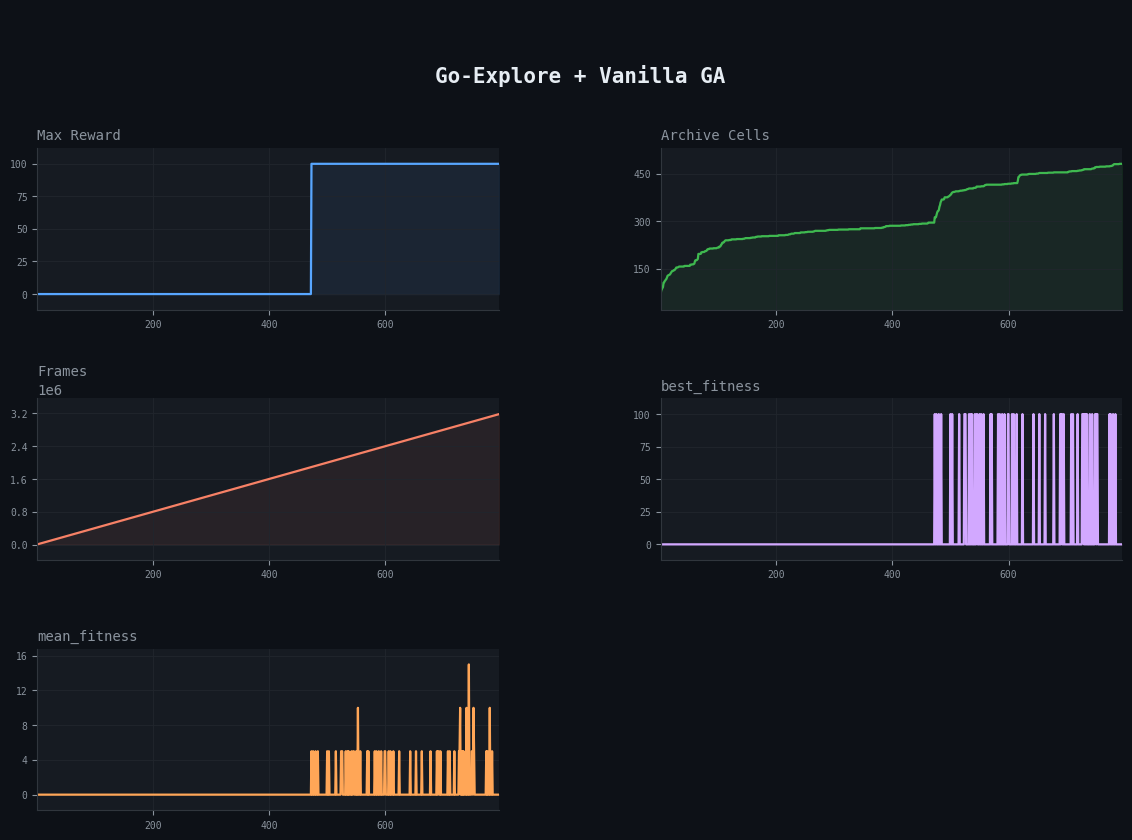

In [ ]:
from collections import defaultdict
import numpy as np
import cv2
import gymnasium as gym
import ale_py
import random
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

dashboard = MetricsDashboard(
    metrics=['max_reward', 'cells', 'frames', 'best_fitness', 'mean_fitness'],
    title='Go-Explore + Vanilla GA', update_every=1,
)

# ──────────────────────────────────────────────
# Go-Explore cell functions (pixel-based)
# ──────────────────────────────────────────────
def cellfn(frame):
    cell = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    cell = cv2.resize(cell, (11, 8), interpolation=cv2.INTER_AREA)
    cell = cell // 32
    return cell

def hashfn(cell):
    return hash(cell.tobytes())

# ──────────────────────────────────────────────
# Go-Explore archive
# ──────────────────────────────────────────────
e1 = 0.001
e2 = 0.00001

class Weights:
    times_chosen           = 0.1
    times_chosen_since_new = 0.0
    times_seen             = 0.3

class Powers:
    times_chosen           = 0.5
    times_chosen_since_new = 0.5
    times_seen             = 0.5

class Cell:
    def __init__(self):
        self.times_chosen           = 0
        self.times_chosen_since_new = 0
        self.times_seen             = 0

    def __setattr__(self, key, value):
        object.__setattr__(self, key, value)
        if key != 'score' and hasattr(self, 'times_seen'):
            self.score = self.cellscore()

    def cntscore(self, a):
        w = getattr(Weights, a)
        p = getattr(Powers, a)
        v = getattr(self, a)
        return w / (v + e1) ** p + e2

    def cellscore(self):
        return (self.cntscore('times_chosen') +
                self.cntscore('times_chosen_since_new') +
                self.cntscore('times_seen') + 1)

    def visit(self):
        self.times_seen += 1
        return self.times_seen == 1

    def choose(self):
        self.times_chosen           += 1
        self.times_chosen_since_new += 1
        return self.ram, self.reward, self.trajectory


# ──────────────────────────────────────────────
# Policy Network
#
# No critic head needed — the GA uses episode return as its fitness
# signal directly. No backprop is ever called on this network.
# ──────────────────────────────────────────────
class PolicyNet(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),             nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),             nn.ReLU(),
        )
        with torch.no_grad():
            feature_size = self.conv(
                torch.zeros(1, *input_shape)
            ).reshape(1, -1).size(1)

        self.fc = nn.Sequential(
            nn.Linear(feature_size, 256), nn.ReLU(),
            nn.Linear(256, n_actions),
        )

    def forward(self, x):
        x = x.float() / 255.
        return self.fc(self.conv(x).reshape(x.size(0), -1))

    def act(self, state_np, device):
        """Greedy action selection — GA policies are deterministic."""
        with torch.no_grad():
            state_t = torch.from_numpy(state_np).permute(2, 0, 1).unsqueeze(0).to(device)
            return self.forward(state_t).argmax(1).item()

    def get_params(self):
        """Return all parameters as a single flat numpy vector."""
        return np.concatenate([p.data.cpu().numpy().ravel()
                               for p in self.parameters()])

    def set_params(self, flat_params):
        """Load a flat numpy parameter vector back into the network."""
        offset = 0
        for p in self.parameters():
            size = p.numel()
            p.data.copy_(
                torch.from_numpy(
                    flat_params[offset : offset + size].reshape(p.shape)
                )
            )
            offset += size


# ──────────────────────────────────────────────
# Vanilla Genetic Algorithm
#
# Implements the simple GA baseline from:
#   "Evolution Strategies as a Scalable Alternative to Reinforcement Learning"
#   Salimans et al., OpenAI, 2017  (Section 6 / Appendix)
#
# Algorithm per generation:
#   1. Evaluate each individual: run its policy in the environment for
#      EVAL_STEPS steps and record the cumulative reward as fitness.
#   2. Truncation selection: rank individuals by fitness, keep the top
#      ELITE_FRAC fraction as parents ("elites").
#   3. Mutation: fill the next population by sampling elites with
#      replacement and adding isotropic Gaussian noise σ to their
#      parameter vectors. One elite is always carried over unchanged
#      (elitism) to prevent the best solution from being lost.
#
# Why GA instead of gradient-based methods:
#   - No backprop, no value function, no replay buffer
#   - Trivially parallelisable — each individual is independent
#   - Robust to sparse rewards since fitness is episodic, not per-step
#   - The mutation operator implicitly explores the parameter space
#     around currently good solutions
#
# Key hyperparameters:
#   POP_SIZE   — larger populations explore more broadly but cost more
#   ELITE_FRAC — fraction of population kept as parents (0.1–0.25 typical)
#   SIGMA      — mutation noise std; too large → random walk, too small → slow
#                The paper uses σ ≈ 0.005–0.02; 0.01 is a good default
# ──────────────────────────────────────────────
class VanillaGA:
    def __init__(self, template_net, pop_size, elite_frac, sigma, device):
        self.pop_size   = pop_size
        self.n_elites   = max(1, int(pop_size * elite_frac))
        self.sigma      = sigma
        self.device     = device

        # Initialise population: one template individual + (pop_size-1) mutations
        base_params = template_net.get_params()
        self.population = []
        for _ in range(pop_size):
            net = copy.deepcopy(template_net).to(device)
            noise = np.random.randn(*base_params.shape) * sigma
            net.set_params(base_params + noise)
            self.population.append(net)

    def evolve(self, fitnesses):
        """
        Given a fitness score for each individual, produce the next generation.

        fitnesses : list of floats, one per individual in self.population

        Returns the elite individuals (useful for logging / archive updates).
        """
        # Rank individuals by fitness (descending)
        ranked = sorted(range(self.pop_size), key=lambda i: fitnesses[i], reverse=True)
        elites = [self.population[i] for i in ranked[:self.n_elites]]

        # Build next generation
        next_pop = []

        # Elitism: carry the single best individual over unchanged
        next_pop.append(copy.deepcopy(elites[0]))

        # Fill the rest by mutating randomly sampled elites
        while len(next_pop) < self.pop_size:
            parent     = random.choice(elites)
            child      = copy.deepcopy(parent)
            params     = child.get_params()
            noise      = np.random.randn(*params.shape) * self.sigma
            child.set_params(params + noise)
            next_pop.append(child)

        self.population = next_pop
        return elites

    def best(self):
        """Return the first individual (best from last evolve call)."""
        return self.population[0]


# ──────────────────────────────────────────────
# State restoration
# ──────────────────────────────────────────────
def restore_env(env, ram):
    env.unwrapped.ale.restoreState(ram)
    return env.unwrapped.ale.getScreenRGB()


def select_cell_from_archive(archive):
    """Score-weighted single cell selection."""
    hashes = list(archive.keys())
    scores = np.array([archive[h].score for h in hashes])
    probs  = scores / scores.sum()
    return hashes[np.random.choice(len(hashes), p=probs)]


# ──────────────────────────────────────────────
# Evaluate one individual from an archive cell
#
# Each individual:
#   1. Is restored to its assigned archive cell (different cell per individual
#      so the population collectively explores the archive frontier)
#   2. Runs its deterministic policy for up to EVAL_STEPS steps
#   3. Returns its cumulative reward as fitness
#   4. Updates the global archive with any novel cells it visits
# ──────────────────────────────────────────────
def evaluate_individual(env, net, device, archive, start_ram, start_score,
                         start_trajectory, eval_steps):
    """
    Returns (fitness, found_new_cell).
    Mutates `archive` in-place.
    """
    state         = restore_env(env, start_ram)
    score         = start_score
    trajectory    = start_trajectory.copy()
    current_lives = get_lives(env)
    found_new     = False

    for _ in range(eval_steps):
        action     = net.act(state, device)
        next_state, reward, terminal, truncated, _ = env.step(action)

        new_lives = get_lives(env)
        life_lost = new_lives < current_lives
        done      = terminal or truncated or life_lost
        current_lives = new_lives

        score += reward
        trajectory.append(action)

        if done:
            break

        # Archive update
        cell_repr   = cellfn(next_state)
        cellhash    = hashfn(cell_repr)
        cell        = archive[cellhash]
        first_visit = cell.visit()

        cell_reward = getattr(cell, 'reward',     -1e9)
        cell_traj   = getattr(cell, 'trajectory', [])
        better  = score > cell_reward
        shorter = score == cell_reward and len(trajectory) < len(cell_traj)

        if first_visit or better or shorter:
            cell.ram        = env.unwrapped.ale.cloneState()
            cell.reward     = score
            cell.trajectory = trajectory.copy()
            cell.times_chosen           = 0
            cell.times_chosen_since_new = 0
            found_new = True

        state = next_state

    # Fitness = reward gained *beyond* the restored cell's baseline
    fitness = score - start_score
    return fitness, found_new


# ──────────────────────────────────────────────
# Hyperparameters
# ──────────────────────────────────────────────
POP_SIZE    = 20      # Number of individuals per generation
ELITE_FRAC  = 0.2     # Top 20% kept as parents → 4 elites for POP_SIZE=20
SIGMA       = 0.01    # Mutation noise std (Salimans et al. use 0.005–0.02)
EVAL_STEPS  = 200     # Max steps each individual is evaluated for per generation
WARMUP_GENS = 10      # Generations of pure random exploration before GA training

archive  = defaultdict(lambda: Cell())
highscore = 0
frames    = 0

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

env      = gym.make('ALE/MontezumaRevenge-v5', render_mode='rgb_array')
obs      = env.observation_space.shape
n_actions = env.action_space.n
input_shape = (obs[2], obs[0], obs[1])

# Seed the archive with a short random episode before GA starts
state, _ = env.reset()
current_lives = get_lives(env)
seed_score = 0
seed_traj  = []
for _ in range(500):
    action     = env.action_space.sample()
    next_state, reward, terminal, truncated, _ = env.step(action)
    new_lives  = get_lives(env)
    life_lost  = new_lives < current_lives
    done       = terminal or truncated or life_lost
    current_lives = new_lives
    seed_score += reward
    seed_traj.append(action)
    frames += 1
    if not done:
        cell_repr = cellfn(next_state)
        h = hashfn(cell_repr)
        cell = archive[h]
        first_visit = cell.visit()
        if first_visit or seed_score > getattr(cell, 'reward', -1e9):
            cell.ram        = env.unwrapped.ale.cloneState()
            cell.reward     = seed_score
            cell.trajectory = seed_traj.copy()
            cell.times_chosen           = 0
            cell.times_chosen_since_new = 0
        state = next_state
    else:
        state, _ = env.reset()
        current_lives = get_lives(env)
        seed_score = 0
        seed_traj  = []

# Initialise GA
template = PolicyNet(input_shape, n_actions).to(device)
ga       = VanillaGA(template, POP_SIZE, ELITE_FRAC, SIGMA, device)

generation = 0

# ──────────────────────────────────────────────
# Main loop — one iteration = one generation
# ──────────────────────────────────────────────
while True:
    fitnesses     = []
    found_new_any = False

    # ── Evaluate each individual ──────────────────────────────────────────────
    # Each individual is assigned a *different* archive cell so the population
    # collectively explores the frontier rather than all competing from the
    # same restored state. Individuals with lower fitness are more likely to
    # be assigned unexplored cells (via the cell score weighting), giving them
    # a chance to improve by discovering novel territory.
    for individual in ga.population:
        if len(archive) > 0:
            h    = select_cell_from_archive(archive)
            cell = archive[h]
            ram, start_score, start_traj = cell.choose()
        else:
            # Fallback: fresh episode if archive somehow empty
            env.reset()
            ram         = env.unwrapped.ale.cloneState()
            start_score = 0
            start_traj  = []

        fitness, found_new = evaluate_individual(
            env, individual, device,
            archive, ram, start_score, start_traj, EVAL_STEPS
        )
        fitnesses.append(fitness)
        frames += EVAL_STEPS   # approximate — actual steps may be less

        total_score = start_score + fitness
        if total_score > highscore:
            highscore = total_score

        if found_new:
            found_new_any = True

    # ── Evolve ────────────────────────────────────────────────────────────────
    if generation >= WARMUP_GENS:
        ga.evolve(fitnesses)

    best_fitness = max(fitnesses)
    mean_fitness = float(np.mean(fitnesses))
    generation  += 1

    print(
        f"Gen: {generation:5d} | Cells: {len(archive):5d} | "
        f"Frames: {frames:8d} | MaxReward: {highscore:.1f} | "
        f"BestFit: {best_fitness:.2f} | MeanFit: {mean_fitness:.2f}"
    )

    dashboard.update(
        iteration   = generation,
        frames      = frames,
        max_reward  = highscore,
        cells       = len(archive),
        best_fitness = best_fitness,
        mean_fitness = mean_fitness,
    )